In [70]:
# Load the libraries

import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Show PyTorch version
torch.__version__

'2.5.1+cu121'

In [71]:
# Setup device agnostic code

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device} is in use")

cuda is in use


## Exercise 1.

### Setting up the data

In [72]:
# parameters

weight = 0.3
bias = 0.9

# function

x_start = 0.0
x_stop = 1.0
n_step = 1000
X = torch.linspace(x_start, x_stop, int(n_step))
Y = weight*x + bias + 0.005*np.random.rand(X.shape[0])

print(X.shape)
print(Y.shape)

torch.Size([1000])
torch.Size([1000])


C:\Users\krzys\AppData\Local\Temp\ipykernel_20240\2276911015.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Y = weight*x + bias + 0.005*np.random.rand(X.shape[0])


In [73]:
train_split = int(0.8*X.shape[0])

X_train, y_train = X[:train_split], Y[:train_split]
X_test,  y_test  = X[train_split:], Y[train_split:]

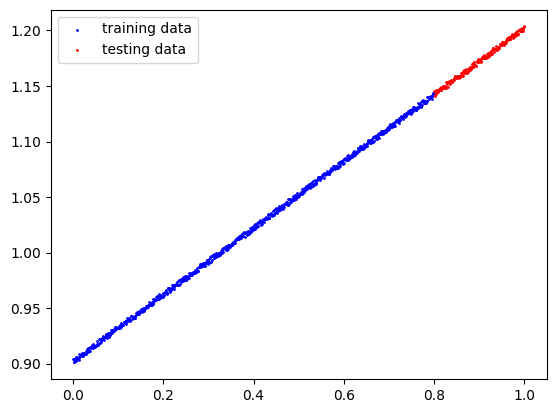

In [74]:
plt.scatter(X_train, y_train, s=1, color="blue", label='training data')
plt.scatter(X_test,  y_test, s=1, color="red", label='testing data')
plt.legend()
plt.show()

### Creating the model

In [75]:
class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.weight = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )

        self.bias = nn.Parameter(
            torch.randn(1, dtype=torch.float),
            requires_grad=True
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight*x + self.bias

In [76]:
torch.manual_seed( int(time.time()) )

model_1 = LinearRegressionModel()

# List named parameters 
model_1.state_dict()

OrderedDict([('weight', tensor([0.3401])), ('bias', tensor([0.2292]))])

### Training

In [77]:
# loss function
loss_fn = nn.L1Loss()

# definition of optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [78]:
# number of epochs
num_epoches = 300

# saving data for training visualization
epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range(num_epoches):

    ### TRAINING

    model_1.train()

    y_pred = model_1(X_train)
    train_loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    ### TESTING

    model_1.eval()

    with torch.inference_mode():

        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)

    
    ### Collecting data for visualization

    if epoch % 20 == 0:

        print(f"Epoch: {epoch} | Training loss: {train_loss} | Test loss: {test_loss}")

        epoch_count.append(epoch)
        train_loss_values.append(train_loss)
        test_loss_values.append(test_loss)

Epoch: 0 | Training loss: 0.6572230605627156 | Test loss: 0.6235646679623486
Epoch: 20 | Training loss: 0.42523926768775355 | Test loss: 0.35155091341570627
Epoch: 40 | Training loss: 0.1932554947244681 | Test loss: 0.0795371475441814
Epoch: 60 | Training loss: 0.05243439679959558 | Test loss: 0.09866314444705244
Epoch: 80 | Training loss: 0.043925885046320765 | Test loss: 0.10063396189376111
Epoch: 100 | Training loss: 0.03707709380728404 | Test loss: 0.08613278005286451
Epoch: 120 | Training loss: 0.03024238750696786 | Test loss: 0.07000975403949018
Epoch: 140 | Training loss: 0.023409892558950176 | Test loss: 0.05420551989241834
Epoch: 160 | Training loss: 0.016582380506592602 | Test loss: 0.038310475684845406
Epoch: 180 | Training loss: 0.009788603611843298 | Test loss: 0.021993995644295175
Epoch: 200 | Training loss: 0.0031842338499784902 | Test loss: 0.006287985183441596
Epoch: 220 | Training loss: 0.006905019249276024 | Test loss: 0.007159524299347358
Epoch: 240 | Training loss:

In [88]:
epoch_count = np.array(epoch_count)
train_loss_values = torch.tensor(train_loss_values).numpy()
test_loss_values = np.array(test_loss_values)

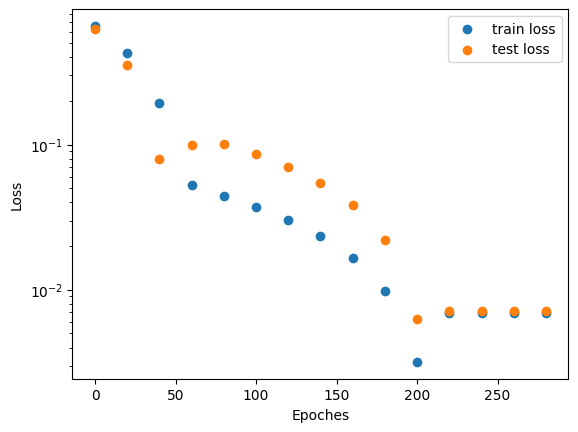

In [92]:
plt.scatter(epoch_count, train_loss_values, label="train loss")
plt.scatter(epoch_count, test_loss_values, label="test loss")
plt.yscale("log")
plt.xlabel("Epoches")
plt.ylabel("Loss")
plt.legend()
plt.show()